# Inspecting a Fitted SGT

A fitted SGT is fully introspectable: `tree_export()` returns a plain dict describing every node — its routing features, bins, child assignments, and leaf statistics. This notebook walks the default univariate structure and pairs it with `plot_tree`.

In [1]:
import json
from sgtlearn import SGTClassifier, plot_tree, make_plus

X, y = make_plus(n_samples=1500, grid=3, margin=0.07, random_state=42)
model = SGTClassifier(max_depth=2, inner_max_depth=2, tao_n_runs=0, random_state=42).fit(X, y)

export = model.tree_export()
print("top-level keys:", list(export))
print("num_partitions:", export["num_partitions"], " num_nodes:", export["num_nodes"], " root:", export["root_index"])

top-level keys: ['num_partitions', 'num_nodes', 'root_index', 'num_classes', 'num_outputs', 'classes_per_output', 'criterion', 'nodes']
num_partitions: 2  num_nodes: 5  root: 0


In [2]:
# Look at the root node's routing rule.
root = export["nodes"][export["root_index"]]
print(json.dumps({k: root[k] for k in root if k != "bin_counts"}, indent=2, default=str))

{
  "id": 0,
  "depth": 0,
  "is_leaf": false,
  "impurity": 0.49777777777777776,
  "class_counts": [
    [
      700.0,
      800.0
    ]
  ],
  "n_samples": 1500,
  "feature": 1,
  "features": [
    1
  ],
  "is_categorical": false,
  "thresholds": [
    0.9987961053848267,
    2.0737411975860596,
    2.9007099866867065
  ],
  "bin_to_partition": [
    1,
    0,
    1,
    1
  ],
  "bin_weights": [
    509.0,
    512.0,
    462.0,
    17.0
  ],
  "bin_sample_counts": [
    509,
    512,
    462,
    17
  ],
  "nan_prediction_partition": 1,
  "children": [
    1,
    2
  ]
}


## Reading a univariate node

- `feature` — the column this node routes on (None at a leaf).
- `thresholds` — the inner-tree bin edges along that feature.
- `bin_to_partition` — for each bin, which child (partition) samples in that bin go to.
- `children` — child node ids, indexed by partition.
- `nan_prediction_partition` — where non-finite values route.
- Leaves carry `class_counts` (classifier) or `value` (regressor) instead of a feature.

The univariate routing rule is exactly: `bin = searchsorted(thresholds, value, side="right")`, then go to `children[bin_to_partition[bin]]`.

Bivariate exports set `routing_kind="pair"` and add `pair_features`, `pair_axes`, `pair_inner_tree`, and `pair_leaf_bins`; missing routing is stored on inner-tree edges rather than in one node-level missing partition. See [S²GT bivariate branching](bivariate-branching.ipynb) for the fitted heatmap.

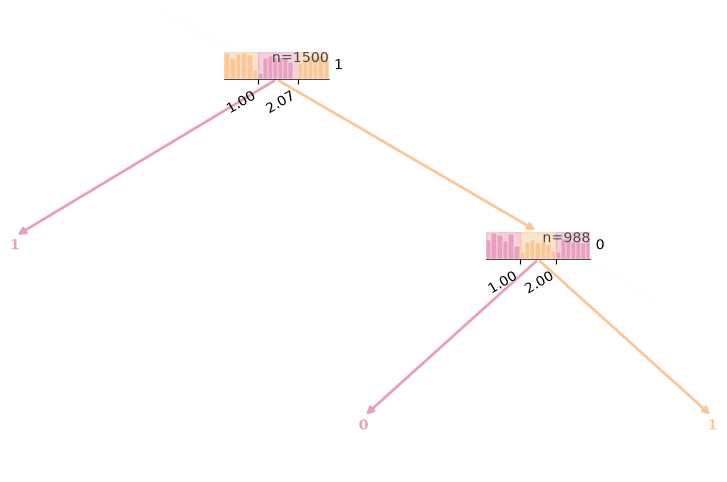

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 6))
plot_tree(model, X=X, ax=ax)   # same tree, visual form of the dict above
plt.show()

## The export is read-only

`tree_export()` returns a **copy**. Mutating it does nothing to the model — there is no supported node-edit API. To change a fitted tree's rules without retraining, use [TAO](tao.ipynb); to change its structure, refit with different [hyperparameters](structure-and-accuracy.ipynb).

In [4]:
# Demonstrate: editing the dict does not affect predictions.
before = model.predict(X[:10])
export["nodes"][export["root_index"]]["feature"] = 999   # mutate the copy
after = model.predict(X[:10])
print("predictions unchanged:", (before == after).all())

predictions unchanged: True
